# 36 — Calculate full, reduced, current and stressed ES

Identify a reduced modellable factor set, select the most severe 12-month window and scale stressed ES.

F,C means Full Current; R,C means Reduced Current; R,S means Reduced Stress. The same reduced factors are used for current and stress calculations.

This step uses: Current and historical factor P&L plus the materiality-ranked reduced set.

It produces: Full current ES, reduced current ES, reduced stress ES, coverage and the scaled measure.

> Basel norm applied: MAR33.5–MAR33.6 require at least 75% reduced-set coverage and floor the scaling ratio at one.

$$ES_{scaled}=ES_{R,S}^{LH}\max\left(\frac{ES_{F,C}^{LH}}{ES_{R,C}^{LH}},1\right)$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
scaled=stage('11_scaled_es_and_imcc'); scan=stage('08_stress_window_scan'); selection=stage('07_reduced_factor_selection')
display(crore_table(scaled,['full_current_es_inr','reduced_current_es_inr','reduced_stress_es_inr','scaled_es_capital_inr']))
allrow=scaled[scaled.scope=='ALL'].iloc[0]
print(f"Reduced-set coverage = {allrow.reduced_set_coverage:.1%}; scaling ratio = max({allrow.full_current_es_inr/allrow.reduced_current_es_inr:.4f}, 1) = {allrow.stress_scaling_ratio:.4f}.")

,scope,Full Current Es (INR crore),Reduced Current Es (INR crore),Reduced Stress Es (INR crore),reduced_set_coverage,stress_scaling_ratio,Scaled Es Capital (INR crore),coverage_requirement,coverage_pass
0,ALL,7.9576,9.0883,25.6659,1.1421,1.0000,25.6659,0.7500,True
1,INTEREST_RATE,0.4587,0.3479,1.2781,0.7586,1.3183,1.6849,0.7500,True
2,CREDIT_SPREAD,0.7812,0.6835,1.4320,0.8748,1.1431,1.6369,0.7500,True
3,EQUITY,4.3323,4.4587,10.0083,1.0292,1.0000,10.0083,0.7500,True
4,FX,1.6926,1.6332,10.2578,0.9649,1.0364,10.6310,0.7500,True
5,COMMODITY,7.1482,8.2966,22.0921,1.1606,1.0000,22.0921,0.7500,True


Reduced-set coverage = 114.2%; scaling ratio = max(0.8756, 1) = 1.0000.


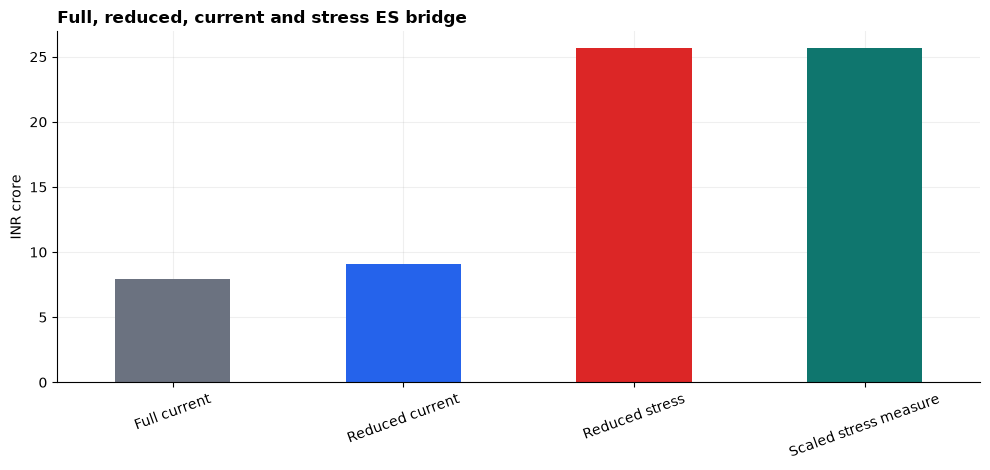

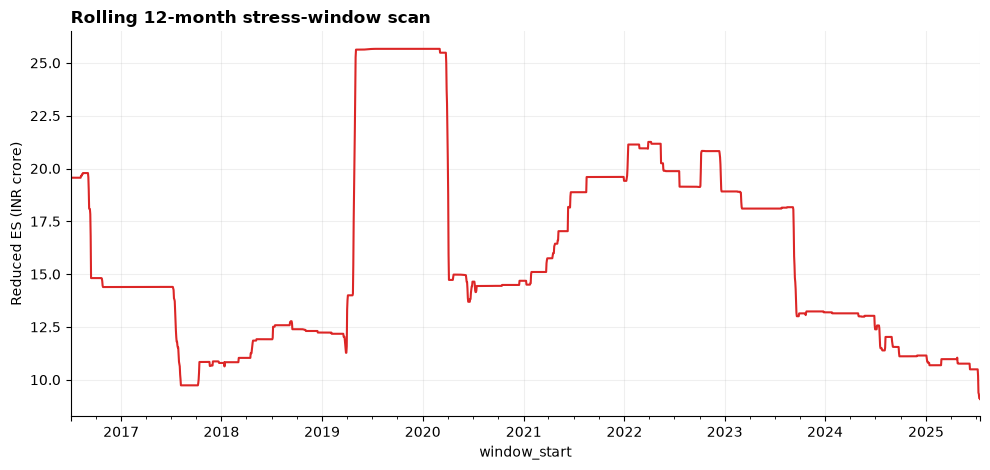

In [3]:
bridge=pd.Series({'Full current':allrow.full_current_es_inr,'Reduced current':allrow.reduced_current_es_inr,'Reduced stress':allrow.reduced_stress_es_inr,'Scaled stress measure':allrow.scaled_es_capital_inr})/INR_CRORE
ax=bridge.plot(kind='bar',color=['#6B7280','#2563EB','#DC2626','#0F766E']); ax.set_ylabel('INR crore'); ax.set_title('Full, reduced, current and stress ES bridge',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=20); plt.tight_layout(); plt.show()
scan['window_start']=pd.to_datetime(scan.window_start); ax=(scan.sort_values('window_start').set_index('window_start').reduced_lh_adjusted_es_inr/INR_CRORE).plot(color='#DC2626'); ax.set_ylabel('Reduced ES (INR crore)'); ax.set_title('Rolling 12-month stress-window scan',loc='left',weight='bold'); plt.tight_layout(); plt.show()

The first chart compares the four quantities used in stressed scaling: full-current ES, reduced-current ES, reduced-stress ES and the resulting scaled measure. The second chart evaluates every rolling 12-month candidate period; its highest point identifies the stress window used for capital rather than a manually selected episode.